<a href="https://colab.research.google.com/github/guilhermef2k/Sistemas_Inteligentes/blob/main/Adaline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 4º Projeto - Sistemas inteligentes
Autores: <br>
Alex Bruno Duarte <br>
Guilherme de França Vasconcelos

## 1. Introdução
---

A ionosfera é a camada da atmosfera terrestre que se estende de aproximadamente 60 a 1.000 km de altitude e é fortemente ionizada pela radiação solar. Seu monitoramento contínuo é essencial para aplicações de telecomunicações, navegação por GPS e previsão de tempestades geomagnéticas. Sistemas de radar de alta frequência (HF) são utilizados para sondar essa camada: pulsos de rádio são emitidos em direção à ionosfera e os sinais refletidos são analisados para determinar se a estrutura ionosférica está bem definida ou não.

O Brasil ocupa uma posição geograficamente privilegiada e ao mesmo tempo desafiadora. O país está situado sobre a Anomalia de Ionização Equatorial, uma região onde a estrutura da ionosfera é altamente irregular e sujeita a perturbações intensas.

## 2. Objetivo
---

Implementar uma Rede Adaline para classificar automaticamente retornos de radar ionosférico, distinguindo sinais que indicam a presença de estrutura eletrônica coerente na ionosfera daqueles que não a indicam.

## 3. Conjunto de dados
---

O projeto utiliza o dataset Ionosphere, disponível no repositório UCI Machine Learning Repository (https://archive.ics.uci.edu/ml/datasets/Ionosphere). O conjunto foi coletado pelo sistema de radar Goose Bay, no Labrador (Canadá), e contribuído por Vince Sigillito do Laboratório de Física Aplicada da Universidade Johns Hopkins. Ele contém 351 amostras de retornos de radar, cada uma descrita por 34 atributos contínuos correspondentes a valores complexos obtidos pela autocorrelação de pulsos de radar emitidos por antenas separadas em fase. O rótulo binário indica se o retorno é good (estrutura ionosférica detectada, classe +1) ou bad (sem estrutura coerente, ou seja, os raios atravessam a ionosfera, classe -1). Do total de amostras, 225 são da classe good e 126 da classe bad.

## 4. Preparação dos dados
---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix)

In [ ]:
url = "https://raw.githubusercontent.com/guilhermef2k/Sistemas_Inteligentes/main/Adaline/dataSet/ionosphere.data"

df = pd.read_csv(url, header=None)
df[34] = np.where(df[34] == 'g', 1, -1)

df = df.loc[:, (df != df.iloc[0]).any()]

df.head()

,0,2,3,4,5,6,7,8,9,10,...,25,26,27,28,29,30,31,32,33,34
0,1,0.99539,-0.05889,0.85243,0.02306,0.83398,-0.37708,1.00000,0.03760,0.85243,...,-0.51171,0.41078,-0.46168,0.21266,-0.34090,0.42267,-0.54487,0.18641,-0.45300,1
1,1,1.00000,-0.18829,0.93035,-0.36156,-0.10868,-0.93597,1.00000,-0.04549,0.50874,...,-0.26569,-0.20468,-0.18401,-0.19040,-0.11593,-0.16626,-0.06288,-0.13738,-0.02447,-1
2,1,1.00000,-0.03365,1.00000,0.00485,1.00000,-0.12062,0.88965,0.01198,0.73082,...,-0.40220,0.58984,-0.22145,0.43100,-0.17365,0.60436,-0.24180,0.56045,-0.38238,1
3,1,1.00000,-0.45161,1.00000,1.00000,0.71216,-1.00000,0.00000,0.00000,0.00000,...,0.90695,0.51613,1.00000,1.00000,-0.20099,0.25682,1.00000,-0.32382,1.00000,-1
4,1,1.00000,-0.02401,0.94140,0.06531,0.92106,-0.23255,0.77152,-0.16399,0.52798,...,-0.65158,0.13290,-0.53206,0.02431,-0.62197,-0.05707,-0.59573,-0.04608,-0.65697,1


In [ ]:
X = df.drop(columns=[34])
y = df[34]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,0,2,3,4,5,6,7,8,9,10,...,24,25,26,27,28,29,30,31,32,33
0,0.348433,0.712372,-0.234257,0.484208,-0.201735,0.577059,-0.954679,0.964074,-0.297510,0.668655,...,0.297728,-0.867565,-0.253868,-0.713971,-0.288290,-0.617039,0.122937,-1.055054,-0.312221,-0.999595
1,0.348433,0.721648,-0.527811,0.634308,-1.037587,-1.339106,-2.029452,0.964074,-0.469482,0.057860,...,-1.037790,-0.383054,-1.447849,-0.208419,-0.989185,-0.173530,-0.909063,-0.115213,-0.932605,-0.083286
2,0.348433,0.721648,-0.176998,0.768477,-0.241309,0.914531,-0.461494,0.746139,-0.350536,0.452533,...,0.310141,-0.651896,0.093506,-0.276586,0.091389,-0.287320,0.441318,-0.464092,0.404443,-0.848591
3,0.348433,0.721648,-1.125172,0.768477,1.921340,0.329433,-2.152585,-1.010873,-0.375331,-0.846256,...,1.045426,1.926340,-0.049490,1.947300,1.080843,-0.341218,-0.167687,1.957315,-1.289826,2.107299
4,0.348433,0.721648,-0.155129,0.655594,-0.109918,0.754068,-0.676741,0.512838,-0.714742,0.092053,...,-0.628910,-1.143025,-0.792950,-0.842112,-0.615818,-1.171144,-0.717726,-1.154227,-0.757673,-1.435736


A normalização dos dados é necessária porque a rede Adaline usa a Regra Delta para aprender. Essa regra ajusta os pesos baseada na taxa de aprendizagem $\eta$ e no erro dos dados.

Se os atributos tiverem tamanhos muito diferentes (por exemplo, um variando entre 0 e 1 e outro entre 100 e 1000), o cálculo matemático fica bagunçado. Isso cria uma superfície de erro com curvaturas desiguais, exigindo taxas de aprendizagem extremamente pequenas para evitar a instabilidade, o que torna a convergência lenta ou impossível sem o escalonamento

## 5. Implementação
---

In [ ]:
# Divisão em 80% treino e 20% teste com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dados divididos. Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras")

Dados divididos. Treino: 280 amostras | Teste: 71 amostras


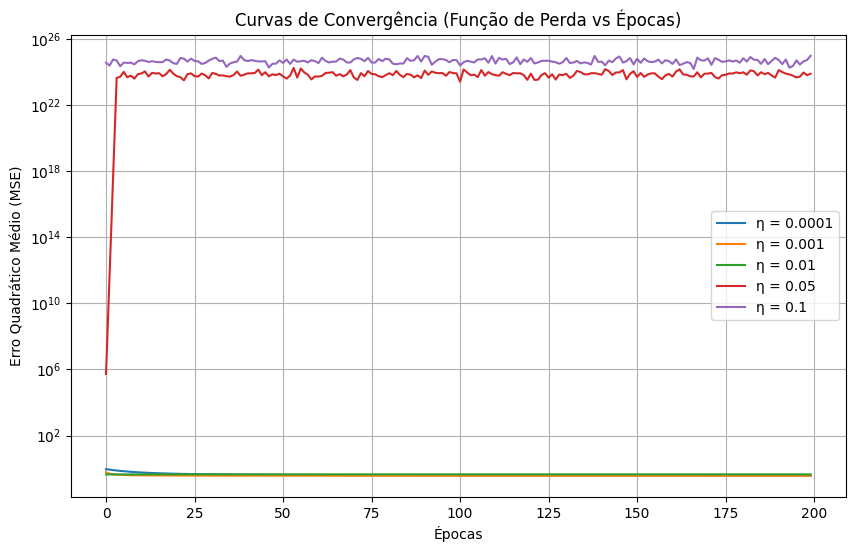

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

taxas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
max_epochs = 200

plt.figure(figsize=(10, 6))

for eta in taxas:
    adaline = SGDClassifier(
        loss='squared_error',
        learning_rate='constant',
        eta0=eta,
        max_iter=1,
        warm_start=True,
        shuffle=True,
        verbose=0,
        random_state=42
    )

    losses = []
    for epoch in range(max_epochs):
        adaline.fit(X_train, y_train)
        y_linear_output = adaline.decision_function(X_train)
        mse = np.mean((y_train - y_linear_output) ** 2)
        losses.append(mse)

    plt.plot(range(max_epochs), losses, label=f'η = {eta}')

plt.title('Curvas de Convergência (Função de Perda vs Épocas)')
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()

O valor de $\eta = 0.001$ foi escolhido por proporcionar uma convergência suave e estável da função de custo (MSE). Diferente das taxas maiores, que causaram a divergência dos pesos e explosão do erro, o $\eta = 0.001$ permitiu que a rede Adaline minimizasse o erro de forma eficiente, alcançando uma acurácia consistente no conjunto de teste sem os riscos de instabilidade do gradiente.

## 6. Avaliação do modelo
---

In [ ]:
melhor_eta = 0.001

adaline_final = SGDClassifier(
    loss='squared_error',
    learning_rate='constant',
    eta0=melhor_eta,
    max_iter=200,
    shuffle=True,
    random_state=42
)

adaline_final.fit(X_train, y_train)

y_pred = adaline_final.predict(X_test)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))
print("\nAcurácia Global:", accuracy_score(y_test, y_pred))

Matriz de Confusão:
[[22  3]
 [ 0 46]]

Acurácia Global: 0.9577464788732394


In [ ]:
acuracia = accuracy_score(y_test, y_pred)
precisao = precision_score(y_test, y_pred)
recall   = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print(f"Acurácia Global: {acuracia:.4f}")
print(f"Precisão (Classe Good): {precisao:.4f}")
print(f"Recall (Classe Good): {recall:.4f}")
print(f"F1-Score (Classe Good): {f1:.4f}")

Acurácia Global: 0.9577
Precisão (Classe Good): 0.9388
Recall (Classe Good): 1.0000
F1-Score (Classe Good): 0.9684


Acurácia (0.9577): O modelo classificou corretamente cerca de 95,7% dos retornos de radar.  

Precisão (0.9388): Quando o modelo afirma que um sinal é "Good", ele está correto em 93,8% das vezes.  

Recall (1.0000): O modelo demonstrou capacidade máxima de identificar sinais que realmente possuem estrutura coerente, atingindo 100% de acerto nessa classe e eliminando "falsos negativos" que poderiam ignorar dados importantes.  

F1-Score (0.9684): O modelo mantém um excelente equilíbrio entre precisão e recall, confirmando ser uma ferramenta de classificação robusta para o monitoramento ionosférico.

### 6.1. Classificação de erro

Em uma aplicação real de monitoramento automático, o erro de classificação mais crítico seria o Falso Positivo (classificar um sinal Bad como Good).

A classe Bad (-1) indica a ausência de estrutura ionosférica coerente, o que pode sinalizar falhas de transmissão ou interferências intensas. Se o sistema comete um Falso Positivo, ele reporta que a estrutura está normal quando, na verdade, há uma perturbação severa. Isso é extremamente perigoso para sistemas de navegação (GPS) e telecomunicações, pois os operadores confiariam em sinais instáveis sem perceber a falha de transmissão. Já um Falso Negativo geraria apenas um alarme falso para verificação, o que é um risco operacional muito menor.

## 7. Conclusão
---

A rede Adaline demonstrou ser altamente adequada para a classificação de retornos de radar ionosférico com base em atributos de autocorrelação complexa. A elevada Acurácia de 0,9577 e o Recall de 1,0000 para a classe "Good" confirmam que o modelo, apesar de sua arquitetura linear simples, é um preditor robusto para identificar estruturas eletrônicas coerentes na ionosfera. A utilização da padronização Z-score e o ajuste criterioso da taxa de aprendizagem ($\eta = 0.001$) foram fundamentais para garantir a convergência estável do algoritmo e evitar a divergência da função de perda. Portanto, o modelo cumpre o objetivo proposto de oferecer uma ferramenta de monitoramento automático eficaz, auxiliando na detecção de irregularidades e contribuindo para a segurança de sistemas críticos de navegação e telecomunicações.